# 3. Why does Lasso produce zero coefficients?

This is the **most important concept** in Lasso Regression.

If you understand this section, the mathematics will become much easier.

---

## First, let's compare the penalties.

### Ridge Regression (L2)

Penalty:

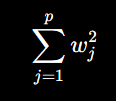

Example:

| Weight | Penalty |
| ------ | ------- |
| 5      | 25      |
| 2      | 4       |
| 1      | 1       |
| 0.5    | 0.25    |

Large weights receive a much larger penalty.

---

### Lasso Regression (L1)

Penalty:

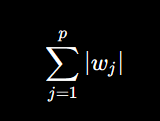

Example:

| Weight | Penalty |
| ------ | ------- |
| 5      | 5       |
| 2      | 2       |
| 1      | 1       |
| 0.5    | 0.5     |

The penalty grows linearly.

---

# Why does this make such a big difference?

Imagine Gradient Descent is trying to reduce the weights.

---

## Ridge

Suppose

```text
Weight = 10
```

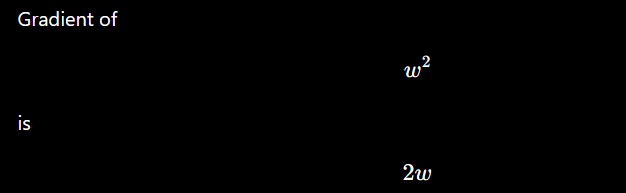

So

```text
Weight = 10

Gradient = 20
```

Large push toward zero.

Now suppose

```text
Weight = 0.2
```

Gradient becomes

```text
0.4
```

Very small push.

When the weight gets close to zero, the force becomes tiny.

Eventually Gradient Descent almost stops moving it.

Result:

```text
10
↓

5

↓

2

↓

0.8

↓

0.2

↓

0.05

↓

0.001

↓

Never exactly 0
```

Ridge shrinks weights but rarely makes them exactly zero.

---

# Lasso behaves differently

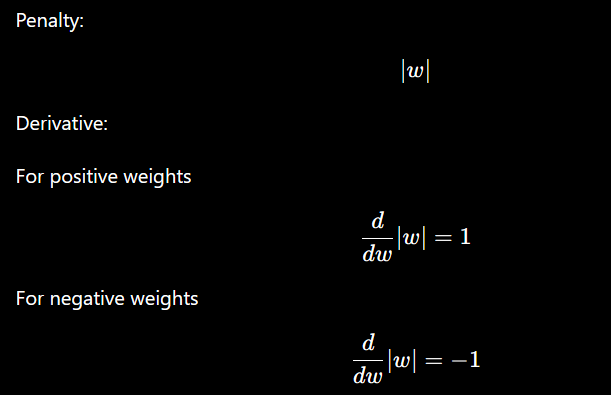

Notice something interesting.

Whether

```text
Weight = 100
```

or

```text
Weight = 0.01
```

the derivative is still

```text
+1
```

(if the weight is positive).

Similarly,

for

```text
Weight = -100
```

and

```text
Weight = -0.01
```

the derivative is always

```text
-1
```

The shrinking force **does not become weaker** as the weight approaches zero.

---

## Compare the shrinking force

| Weight | Ridge Gradient | Lasso Gradient |
| ------ | -------------: | -------------: |
| 10     |             20 |              1 |
| 5      |             10 |              1 |
| 1      |              2 |              1 |
| 0.5    |              1 |              1 |
| 0.1    |            0.2 |              1 |
| 0.01   |           0.02 |              1 |

Notice:

* Ridge's force decreases as the weight gets smaller.
* Lasso keeps applying the same shrinking force until the weight reaches zero.

---

## What happens during Gradient Descent?

Suppose

```text
Weight = 0.15
Learning Rate = 0.1
```

Lasso update:

```text
New Weight

= 0.15 − 0.1 × 1

= 0.05
```

Next step:

```text
0.05 − 0.1

= -0.05
```

In practice, optimization algorithms detect this crossing and **set the coefficient to exactly zero** rather than letting it oscillate around zero.

This is why Lasso performs feature selection.

---

# Key intuition

* **Ridge (L2)** acts like a **rubber band**. As the weight gets close to zero, the pull becomes weaker.
* **Lasso (L1)** acts like a **constant tug**. It keeps pulling with the same strength until the weight reaches zero.

That's why:

* Ridge → coefficients become **small**.
* Lasso → some coefficients become **exactly zero**.

---

## Summary

| Property                        | Ridge (L2) | Lasso (L1)                          |   |   |
| ------------------------------- | ---------- | ----------------------------------- | - | - |
| Penalty                         | (w^2)      | (                                   | w | ) |
| Gradient                        | (2w)       | (+1), (-1) (undefined exactly at 0) |   |   |
| Shrinks coefficients            | ✅ Yes      | ✅ Yes                               |   |   |
| Makes coefficients exactly zero | ❌ Rarely   | ✅ Yes                               |   |   |
| Feature selection               | ❌ No       | ✅ Yes                               |   |   |

---